# HW14: Intro to NN, Classification

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
from keras.callbacks import History, Callback
from keras.optimizers import SGD, Adam
from keras.wrappers.scikit_learn import KerasClassifier
from keras import optimizers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder


Using TensorFlow backend.


In [2]:
%load_ext pycodestyle_magic

This code should prevent tensorflow from eating all the gpu memory:

In [3]:
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

## Import

In [4]:
df = pd.read_csv('data/loans.csv', index_col=0)

In [5]:
df.head()

,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,DisbursalDate,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
UniqueID,,,,,,,,,,,,,,,,,,,,,
750296,42996,69150,63.60,18,22708,86,2728,31-12-88,Salaried,04-08-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
652580,37941,45536,84.68,5,13942,51,3425,01-01-78,Self employed,21-09-18,...,0,0,6298,0,1,0,0yrs 10mon,1yrs 5mon,0,0
697940,48651,65138,76.76,61,15897,45,1377,01-01-64,Salaried,12-10-18,...,0,0,100000,0,0,0,0yrs 8mon,1yrs 1mon,0,0
703152,60215,72684,83.88,136,17783,86,3708,10-08-98,NaN,20-10-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
603556,59615,72086,84.89,19,16938,86,1853,30-01-85,Self employed,14-10-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


## Preprocess

In [6]:
enc = OneHotEncoder(sparse=False, categories='auto')

In [7]:
def preprocess(df, is_train=False):
    df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1]).astype(int)

    df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900)
    + (df['birth_year'] < 40) * (df['birth_year'] + 2000)

    df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1]).astype(int)

    df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900)
    + (df['disb_year'] < 40) * (df['disb_year'] + 2000)

    df['customer_age'] = df['disb_year'] - df['birth_year']

    df = df.drop(['Date.of.Birth', 'DisbursalDate', 'birth_year', 'disb_year'],
                 axis=1)

    df['Employment.Type'] = df['Employment.Type'] == 'Salaried'

    df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(
        '|'.join(['Not Scored', 'No Bureau'])),
           'PERFORM_CNS.SCORE.DESCRIPTION'] = ''

    riskvals = ['Very Low Risk', 'Low Risk', 'Medium Risk',
                'High Risk', 'Very High Risk']
    for r in riskvals:
        df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

    df['account_months'] = (df['AVERAGE.ACCT.AGE']
                            .str.split('yrs').str[0]).astype(int) * 12 +\
    df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1].str.split('mon').str[0].\
        astype(int)

    df['credit_months'] = (df['CREDIT.HISTORY.LENGTH']
                           .str.split('yrs').str[0]).astype(int) * 12 +\
    df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1].str.split('mon')\
        .str[0].astype(int)

    df = df.drop(df.columns[df.dtypes == 'object'], axis=1)

    df = df.drop(['supplier_id', 'Current_pincode_ID',
                  'Employee_code_ID'], axis=1)

    oh_cols = ['manufacturer_id', 'branch_id', 'State_ID']
    if is_train:
        oh_df = pd.DataFrame(enc.fit_transform(df[oh_cols]),
                             columns=enc.get_feature_names(oh_cols),
                             index=df.index)
    else:
        oh_df = pd.DataFrame(enc.transform(df[oh_cols]),
                     columns=enc.get_feature_names(oh_cols),
                     index=df.index)

    df = pd.concat([df, oh_df], axis=1)
    df = df.drop(oh_cols, axis=1)

    return df

In [8]:
df_trans = preprocess(df, is_train=True)

In [9]:
df_trans.columns[df_trans.dtypes == 'object']

Index([], dtype='object')

In [10]:
train_data, test_data = train_test_split(df_trans, test_size=0.2, random_state=42)

In [11]:
def scale(data_frame, scaler):
    data_frame = pd.DataFrame(
        data=scaler.transform(data_frame.to_numpy()),
        columns=data_frame.columns,
        index=data_frame.index
    )
    return data_frame

def xy_split(data_frame):
    x = data_frame.drop(['loan_default'], axis=1)
    y = data_frame['loan_default']
    return x, y

In [12]:
X_train, y_train = xy_split(train_data)
X_test, y_test = xy_split(test_data)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scale(X_train, scaler)
X_test = scale(X_test, scaler)

## Model

Firstly, trying with no hidden layers

In [13]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='sigmoid'))
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 1)                 151       
Total params: 151
Trainable params: 151
Non-trainable params: 0
_________________________________________________________________
None


Defining ROC-AUC Callback (https://www.kaggle.com/tilii7/keras-averaging-runs-gini-early-stopping):

In [14]:
class roc_auc_callback(Callback):
    def __init__(self, training_data, validation_data):
        self.x = training_data[0]
        self.y = training_data[1]
        self.x_val = validation_data[0]
        self.y_val = validation_data[1]

    def on_train_begin(self, logs={}):
        return

    def on_train_end(self, logs={}):
        return

    def on_epoch_begin(self, epoch, logs={}):
        return

    def on_epoch_end(self, epoch, logs={}):
        y_pred = self.model.predict_proba(self.x, verbose=0)
        roc = roc_auc_score(self.y, y_pred)
        logs['roc_auc'] = roc_auc_score(self.y, y_pred)

        y_pred_val = self.model.predict_proba(self.x_val, verbose=0)
        roc_val = roc_auc_score(self.y_val, y_pred_val)
        logs['roc_auc_val'] = roc_auc_score(self.y_val, y_pred_val)

        print('\rroc_auc: %s - roc_auc_val: %s' % (str(round(roc, 5)),
                                                   str(round(roc_val, 5))),
              end=10*' '+'\n')
        return

    def on_batch_begin(self, batch, logs={}):
        return

    def on_batch_end(self, batch, logs={}):
        return

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
batch = 32
epoch = 20
split = 0.2
sh = True

In [17]:
callbacks_list = [roc_auc_callback(training_data=(X_train, y_train),
                                   validation_data=(X_test, y_test))]

In [18]:
np.random.seed(42)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch,
    epochs=epoch,
    validation_split=split,
    shuffle=sh,
    callbacks=callbacks_list
    )

Train on 14921 samples, validate on 3731 samples
Epoch 1/20
14921/14921 [==============================] - 1s 92us/step - loss: 0.7189 - accuracy: 0.5975 - val_loss: 0.6215 - val_accuracy: 0.6872
roc_auc: 0.59758 - roc_auc_val: 0.59888          
Epoch 2/20
14921/14921 [==============================] - 1s 68us/step - loss: 0.5734 - accuracy: 0.7420 - val_loss: 0.5523 - val_accuracy: 0.7564
roc_auc: 0.63955 - roc_auc_val: 0.62942          
Epoch 3/20
14921/14921 [==============================] - 1s 66us/step - loss: 0.5303 - accuracy: 0.7721 - val_loss: 0.5261 - val_accuracy: 0.7711
roc_auc: 0.65224 - roc_auc_val: 0.63969          
Epoch 4/20
14921/14921 [==============================] - 1s 66us/step - loss: 0.5140 - accuracy: 0.7761 - val_loss: 0.5181 - val_accuracy: 0.7735
roc_auc: 0.65473 - roc_auc_val: 0.63992          
Epoch 5/20
14921/14921 [==============================] - 1s 68us/step - loss: 0.5081 - accuracy: 0.7779 - val_loss: 0.5153 - val_accuracy: 0.7743
roc_auc: 0.65687

In [19]:
roc_auc_score(y_test, model.predict(X_test).reshape(-1))

0.6377871188033383

Plotting loss:

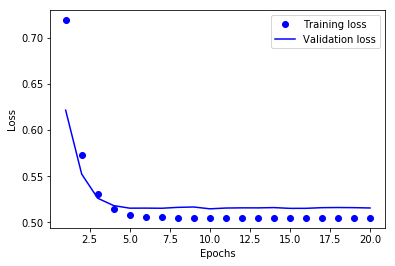

In [20]:
history_dict = history.history
acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Trying the same model, but with a learning rate scheduler:

In [21]:
batch = 32
epoch = 20
split = 0.2
sh = True
lr = 0.001

In [25]:
def decay_rate(epoch):
    return lr * np.exp(-0.15*epoch)

In [26]:
loss_history = History()
lr_rate = LearningRateScheduler(decay_rate, verbose=1)

callbacks_list = [roc_auc_callback(training_data=(X_train, y_train),
                                   validation_data=(X_test, y_test)),
                 lr_rate, loss_history]

In [27]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

np.random.seed(42)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch,
    epochs=epoch,
    validation_split=split,
    shuffle=sh,
    callbacks=callbacks_list
    )

Train on 14921 samples, validate on 3731 samples
Epoch 1/20

Epoch 00001: LearningRateScheduler setting learning rate to 0.001.
14921/14921 [==============================] - 2s 111us/step - loss: 0.6963 - accuracy: 0.6236 - val_loss: 0.6053 - val_accuracy: 0.7146
roc_auc: 0.6114 - roc_auc_val: 0.59521          
Epoch 2/20

Epoch 00002: LearningRateScheduler setting learning rate to 0.0008607079764250578.
14921/14921 [==============================] - 2s 104us/step - loss: 0.5747 - accuracy: 0.7439 - val_loss: 0.5537 - val_accuracy: 0.7604
roc_auc: 0.64026 - roc_auc_val: 0.62348          
Epoch 3/20

Epoch 00003: LearningRateScheduler setting learning rate to 0.0007408182206817179.
14921/14921 [==============================] - 2s 114us/step - loss: 0.5360 - accuracy: 0.7695 - val_loss: 0.5311 - val_accuracy: 0.7695
roc_auc: 0.65238 - roc_auc_val: 0.63739          
Epoch 4/20

Epoch 00004: LearningRateScheduler setting learning rate to 0.0006376281516217733.
14921/14921 [==============

Doesn't really make much of a difference:

In [28]:
roc_auc_score(y_test, model.predict(X_test).reshape(-1))

0.6405010593231807

### Adding a hidden layer

In order to avoid searching parameters by hand, creating a KerasClassifier model:

In [29]:
def create_model(nodes=16, activation0='relu',
                 drop=0.1, activation1='sigmoid',
                 opt='sgd'):
    # define model
    model = Sequential()
    model.add(Dense(nodes, input_shape=(X_train.shape[1],),
                    activation=activation0))
    model.add(Dropout(drop))
    model.add(Dense(nodes, activation=activation0))
    model.add(Dense(1, activation=activation1))

    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    return model

In [30]:
model_CV = KerasClassifier(build_fn=create_model, epochs=10, 
                           batch_size=batch, verbose=1)

In [31]:
param_grid = {
    'nodes': [8, 16, 32, 64],
    'activation0': ['relu', 'tanh', 'sigmoid'],
    'drop': [0., 0.1, 0.2, 0.5],
    'activation1': ['relu', 'tanh', 'sigmoid'],
    'opt': ['adam']
}

In [32]:
grid = RandomizedSearchCV(estimator=model_CV, param_distributions=param_grid,
                          cv=5, verbose=100, scoring='roc_auc')
grid_result = grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] opt=adam, nodes=32, drop=0.2, activation1=tanh, activation0=relu 
Epoch 1/10
14921/14921 [==============================] - 2s 127us/step - loss: 1.8796 - accuracy: 0.5225
Epoch 2/10
14921/14921 [==============================] - 2s 108us/step - loss: 1.3074 - accuracy: 0.5816
Epoch 3/10
14921/14921 [==============================] - 2s 107us/step - loss: 0.9198 - accuracy: 0.6149
Epoch 4/10
14921/14921 [==============================] - 2s 108us/step - loss: 0.8115 - accuracy: 0.6652
Epoch 5/10
14921/14921 [==============================] - 2s 110us/step - loss: 0.6988 - accuracy: 0.7048
Epoch 6/10
14921/14921 [==============================] - 2s 117us/step - loss: 0.6581 - accuracy: 0.7260
Epoch 7/10
14921/14921 [==============================] - 2s 117us/step - loss: 0.6248 - accuracy: 0.7263
Epoch 8/10
14921/14921 [=====================

Epoch 1/10
14921/14921 [==============================] - 2s 107us/step - loss: 1.5343 - accuracy: 0.5806
Epoch 2/10
14921/14921 [==============================] - 1s 98us/step - loss: 0.8117 - accuracy: 0.6723
Epoch 3/10
14921/14921 [==============================] - 2s 112us/step - loss: 0.7133 - accuracy: 0.7190
Epoch 4/10
14921/14921 [==============================] - 2s 103us/step - loss: 0.6749 - accuracy: 0.7311
Epoch 5/10
14921/14921 [==============================] - 2s 103us/step - loss: 0.6293 - accuracy: 0.7105
Epoch 6/10
14921/14921 [==============================] - 2s 147us/step - loss: 0.6569 - accuracy: 0.7123
Epoch 7/10
14921/14921 [==============================] - 2s 125us/step - loss: 0.6331 - accuracy: 0.7142
Epoch 8/10
14921/14921 [==============================] - 2s 124us/step - loss: 0.6453 - accuracy: 0.7308
Epoch 9/10
14921/14921 [==============================] - 2s 118us/step - loss: 0.6057 - accuracy: 0.7441
Epoch 10/10
3731/3731 [========================

Epoch 1/10
14922/14922 [==============================] - 1s 96us/step - loss: 3.2124 - accuracy: 0.5752
Epoch 2/10
14922/14922 [==============================] - 1s 85us/step - loss: 1.5962 - accuracy: 0.6659
Epoch 3/10
14922/14922 [==============================] - 1s 89us/step - loss: 1.1226 - accuracy: 0.6971
Epoch 4/10
14922/14922 [==============================] - 1s 85us/step - loss: 0.8984 - accuracy: 0.7294
Epoch 5/10
14922/14922 [==============================] - 1s 84us/step - loss: 0.7954 - accuracy: 0.7398
Epoch 6/10
14922/14922 [==============================] - 1s 85us/step - loss: 0.7035 - accuracy: 0.7533
Epoch 7/10
14922/14922 [==============================] - 1s 87us/step - loss: 0.7002 - accuracy: 0.7585
Epoch 8/10
14922/14922 [==============================] - 1s 86us/step - loss: 0.6484 - accuracy: 0.7640
Epoch 9/10
14922/14922 [==============================] - 1s 88us/step - loss: 0.6275 - accuracy: 0.7648
Epoch 10/10
3730/3730 [==============================] 

Epoch 1/10
14922/14922 [==============================] - 2s 121us/step - loss: 0.5928 - accuracy: 0.7255
Epoch 2/10
14922/14922 [==============================] - 2s 103us/step - loss: 0.5165 - accuracy: 0.7789
Epoch 3/10
14922/14922 [==============================] - 2s 103us/step - loss: 0.5090 - accuracy: 0.7796
Epoch 4/10
14922/14922 [==============================] - 2s 104us/step - loss: 0.5051 - accuracy: 0.7799
Epoch 5/10
14922/14922 [==============================] - 2s 103us/step - loss: 0.5018 - accuracy: 0.7807
Epoch 6/10
14922/14922 [==============================] - 2s 103us/step - loss: 0.5005 - accuracy: 0.7805
Epoch 7/10
14922/14922 [==============================] - 2s 106us/step - loss: 0.4983 - accuracy: 0.7818
Epoch 8/10
14922/14922 [==============================] - 2s 105us/step - loss: 0.4974 - accuracy: 0.7807
Epoch 9/10
14922/14922 [==============================] - 2s 103us/step - loss: 0.4968 - accuracy: 0.7811
Epoch 10/10
3730/3730 [=======================

Epoch 1/10
14922/14922 [==============================] - 2s 124us/step - loss: 0.5354 - accuracy: 0.7784
Epoch 2/10
14922/14922 [==============================] - 2s 110us/step - loss: 0.5152 - accuracy: 0.7784
Epoch 3/10
14922/14922 [==============================] - 2s 108us/step - loss: 0.5120 - accuracy: 0.7784
Epoch 4/10
14922/14922 [==============================] - 2s 109us/step - loss: 0.5121 - accuracy: 0.7784
Epoch 5/10
14922/14922 [==============================] - 2s 110us/step - loss: 0.5133 - accuracy: 0.7785
Epoch 6/10
14922/14922 [==============================] - 2s 109us/step - loss: 0.5069 - accuracy: 0.7784
Epoch 7/10
14922/14922 [==============================] - 2s 109us/step - loss: 0.5150 - accuracy: 0.7784
Epoch 8/10
14922/14922 [==============================] - 2s 111us/step - loss: 0.5059 - accuracy: 0.7784
Epoch 9/10
14922/14922 [==============================] - 2s 109us/step - loss: 0.5060 - accuracy: 0.7784
Epoch 10/10
3730/3730 [=======================

Epoch 1/10
14921/14921 [==============================] - 2s 105us/step - loss: 0.5231 - accuracy: 0.7792
Epoch 2/10
14921/14921 [==============================] - 1s 96us/step - loss: 0.5111 - accuracy: 0.7792
Epoch 3/10
14921/14921 [==============================] - 1s 96us/step - loss: 0.5049 - accuracy: 0.7792
Epoch 4/10
14921/14921 [==============================] - 1s 97us/step - loss: 0.5021 - accuracy: 0.7792
Epoch 5/10
14921/14921 [==============================] - 1s 96us/step - loss: 0.5005 - accuracy: 0.7792
Epoch 6/10
14921/14921 [==============================] - 1s 95us/step - loss: 0.4998 - accuracy: 0.7792
Epoch 7/10
14921/14921 [==============================] - 1s 96us/step - loss: 0.4988 - accuracy: 0.7792
Epoch 8/10
14921/14921 [==============================] - 1s 97us/step - loss: 0.4985 - accuracy: 0.7792
Epoch 9/10
14921/14921 [==============================] - 1s 98us/step - loss: 0.4977 - accuracy: 0.7792
Epoch 10/10
3731/3731 [==============================]

Epoch 1/10
14921/14921 [==============================] - 2s 115us/step - loss: 0.5260 - accuracy: 0.7772
Epoch 2/10
14921/14921 [==============================] - 2s 103us/step - loss: 0.5150 - accuracy: 0.7774
Epoch 3/10
14921/14921 [==============================] - 2s 102us/step - loss: 0.5131 - accuracy: 0.7772
Epoch 4/10
14921/14921 [==============================] - 2s 102us/step - loss: 0.5110 - accuracy: 0.7773
Epoch 5/10
14921/14921 [==============================] - 2s 102us/step - loss: 0.5087 - accuracy: 0.7776
Epoch 6/10
14921/14921 [==============================] - 2s 102us/step - loss: 0.5083 - accuracy: 0.7779
Epoch 7/10
14921/14921 [==============================] - 2s 101us/step - loss: 0.5081 - accuracy: 0.7776
Epoch 8/10
14921/14921 [==============================] - 2s 104us/step - loss: 0.5068 - accuracy: 0.7772
Epoch 9/10
14921/14921 [==============================] - 2s 103us/step - loss: 0.5061 - accuracy: 0.7782
Epoch 10/10
3731/3731 [=======================

Epoch 1/10
14922/14922 [==============================] - 1s 96us/step - loss: 1.6892 - accuracy: 0.5053
Epoch 2/10
14922/14922 [==============================] - 1s 91us/step - loss: 0.9039 - accuracy: 0.6248
Epoch 3/10
14922/14922 [==============================] - 1s 86us/step - loss: 0.7497 - accuracy: 0.6751
Epoch 4/10
14922/14922 [==============================] - 1s 84us/step - loss: 0.6723 - accuracy: 0.7235
Epoch 5/10
14922/14922 [==============================] - 1s 87us/step - loss: 0.6382 - accuracy: 0.7352
Epoch 6/10
14922/14922 [==============================] - 1s 83us/step - loss: 0.5867 - accuracy: 0.7494
Epoch 7/10
14922/14922 [==============================] - 1s 84us/step - loss: 0.6067 - accuracy: 0.7262
Epoch 8/10
14922/14922 [==============================] - 1s 87us/step - loss: 0.6041 - accuracy: 0.7315
Epoch 9/10
14922/14922 [==============================] - 1s 89us/step - loss: 0.5678 - accuracy: 0.7577
Epoch 10/10
3730/3730 [==============================] 

Epoch 1/10
14922/14922 [==============================] - 2s 122us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 2/10
14922/14922 [==============================] - 2s 107us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 3/10
14922/14922 [==============================] - 2s 108us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 4/10
14922/14922 [==============================] - 2s 111us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 5/10
14922/14922 [==============================] - 2s 108us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 6/10
14922/14922 [==============================] - 2s 108us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 7/10
14922/14922 [==============================] - 2s 108us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 8/10
14922/14922 [==============================] - 2s 106us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 9/10
14922/14922 [==============================] - 2s 107us/step - loss: 3.3844 - accuracy: 0.7806
Epoch 10/10
3730/3730 [=======================

In [33]:
grid_result.best_params_

{'opt': 'adam',
 'nodes': 8,
 'drop': 0.0,
 'activation1': 'sigmoid',
 'activation0': 'sigmoid'}

In [34]:
grid_result.best_score_

0.6441407809512835

In [35]:
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print(f' mean={mean:.4}, std={stdev:.4} using {param}')

 mean=0.5888, std=0.0107 using {'opt': 'adam', 'nodes': 32, 'drop': 0.2, 'activation1': 'tanh', 'activation0': 'relu'}
 mean=0.5921, std=0.0176 using {'opt': 'adam', 'nodes': 32, 'drop': 0.1, 'activation1': 'tanh', 'activation0': 'relu'}
 mean=0.5303, std=0.0155 using {'opt': 'adam', 'nodes': 8, 'drop': 0.5, 'activation1': 'relu', 'activation0': 'relu'}
 mean=0.6348, std=0.005937 using {'opt': 'adam', 'nodes': 16, 'drop': 0.2, 'activation1': 'sigmoid', 'activation0': 'relu'}
 mean=0.5902, std=0.06517 using {'opt': 'adam', 'nodes': 16, 'drop': 0.2, 'activation1': 'tanh', 'activation0': 'sigmoid'}
 mean=0.6151, std=0.05765 using {'opt': 'adam', 'nodes': 8, 'drop': 0.1, 'activation1': 'relu', 'activation0': 'sigmoid'}
 mean=0.6441, std=0.00556 using {'opt': 'adam', 'nodes': 8, 'drop': 0.0, 'activation1': 'sigmoid', 'activation0': 'sigmoid'}
 mean=0.6429, std=0.003843 using {'opt': 'adam', 'nodes': 64, 'drop': 0.5, 'activation1': 'sigmoid', 'activation0': 'sigmoid'}
 mean=0.5909, std=0.018

Running the best params model with previously defined callbacks (roc_auc and learning rate scheduler)

In [36]:
model = create_model(**grid_result.best_params_)

In [37]:
model.summary()

Model: "sequential_55"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_157 (Dense)            (None, 8)                 1208      
_________________________________________________________________
dropout_52 (Dropout)         (None, 8)                 0         
_________________________________________________________________
dense_158 (Dense)            (None, 8)                 72        
_________________________________________________________________
dense_159 (Dense)            (None, 1)                 9         
Total params: 1,289
Trainable params: 1,289
Non-trainable params: 0
_________________________________________________________________


In [38]:
history = model.fit(
    X_train,
    y_train,
    batch_size=batch,
    epochs=epoch,
    validation_split=split,
    shuffle=sh,
    callbacks=callbacks_list
    )

Train on 14921 samples, validate on 3731 samples
Epoch 1/20

Epoch 00001: LearningRateScheduler setting learning rate to 0.001.
14921/14921 [==============================] - 2s 119us/step - loss: 0.5225 - accuracy: 0.7784 - val_loss: 0.5220 - val_accuracy: 0.7749
roc_auc: 0.63248 - roc_auc_val: 0.62541          
Epoch 2/20

Epoch 00002: LearningRateScheduler setting learning rate to 0.0008607079764250578.
14921/14921 [==============================] - 2s 108us/step - loss: 0.5121 - accuracy: 0.7784 - val_loss: 0.5159 - val_accuracy: 0.7749
roc_auc: 0.64858 - roc_auc_val: 0.63866          
Epoch 3/20

Epoch 00003: LearningRateScheduler setting learning rate to 0.0007408182206817179.
14921/14921 [==============================] - 2s 106us/step - loss: 0.5064 - accuracy: 0.7784 - val_loss: 0.5137 - val_accuracy: 0.7749
roc_auc: 0.65537 - roc_auc_val: 0.64311          
Epoch 4/20

Epoch 00004: LearningRateScheduler setting learning rate to 0.0006376281516217733.
14921/14921 [=============

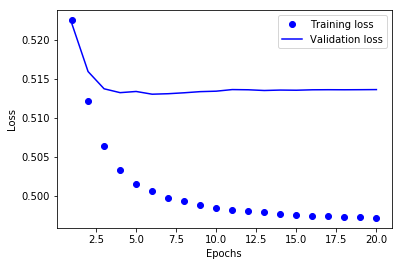

In [39]:
history_dict = history.history
acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

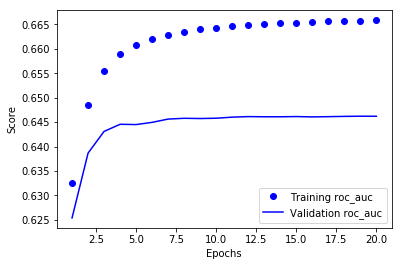

In [40]:
history_dict = history.history
acc_values = history_dict['roc_auc']
val_acc_values = history_dict['roc_auc_val']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Training roc_auc')
plt.plot(epochs, val_acc_values, 'b', label='Validation roc_auc')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.show()

That looks a bit better:

In [41]:
roc_auc_score(y_test, model.predict(X_test).reshape(-1))

0.6462028379251773